# پروژه پیش‌بینی شاخص بورس ایران
## Notebook 01 — مدل XGBoost

**هدف:** پیش‌بینی شاخص بورس با استفاده از XGBoost (Extreme Gradient Boosting)

| موضوع | جزئیات |
|-------|---------|
| متغیر هدف | `log_return` (بازده لگاریتمی) |
| ویژگی‌ها | ۲۴ ویژگی: کلان‌اقتصادی + تعاملی + lag + rolling |
| اعتبارسنجی | TimeSeriesSplit (5 fold) |
| تفسیرپذیری | SHAP values |
| نمودارها | ۱۳ نمودار از ۸ نوع مختلف |

> **پیش‌نیاز:** ابتدا `00_data_preparation.ipynb` را اجرا کنید.

## ۱. بارگذاری کتابخانه‌ها

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb
import shap
import joblib

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import gaussian_kde, probplot
from scipy.stats import randint, uniform

import arabic_reshaper
from bidi.algorithm import get_display

sys.path.append("..")
from src.utils import load_data, get_train_test

# ── تابع اصلاح فارسی برای matplotlib
def fp(text):
    return get_display(arabic_reshaper.reshape(str(text)))

plt.rcParams["figure.dpi"]  = 120
plt.rcParams["grid.alpha"]  = 0.3
plt.rcParams["font.family"] = "DejaVu Sans"
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"✓ XGBoost  : {xgb.__version__}")
print(f"✓ SHAP     : {shap.__version__}")
print("✓ کتابخانه‌ها آماده‌اند")

✓ XGBoost  : 3.2.0
✓ SHAP     : 0.51.0
✓ کتابخانه‌ها آماده‌اند


## ۲. بارگذاری داده و مهندسی ویژگی

علاوه بر ۱۵ ویژگی پایه، ویژگی‌های جدید اضافه می‌کنیم:
- **Lag features:** بازده ۱ تا ۴ فصل قبل (حافظه کوتاه‌مدت)
- **Rolling statistics:** میانگین و انحراف معیار ۴ و ۸ فصله
- **YoY change:** تغییر سالیانه نفت و نرخ ارز

In [2]:
df = load_data()
train, test = get_train_test(df, test_quarters=16)

MACRO_COLS = [
    "oil", "gold", "export", "import", "exchange", "liquidity", "cpi", "cycle",
    "oil_x_cycle", "gold_x_cycle", "export_x_cycle", "import_x_cycle",
    "exchange_x_cycle", "liquidity_x_cycle", "cpi_x_cycle"
]

def build_features(df_full, df_split):
    tmp = df_full.copy()
    for lag in [1, 2, 3, 4]:
        tmp[f"lr_lag{lag}"] = tmp["log_return"].shift(lag)
    tmp["lr_roll_mean4"] = tmp["log_return"].rolling(4).mean()
    tmp["lr_roll_std4"]  = tmp["log_return"].rolling(4).std()
    tmp["lr_roll_mean8"] = tmp["log_return"].rolling(8).mean()
    tmp["oil_yoy"]       = tmp["oil"].pct_change(4)
    tmp["exchange_yoy"]  = tmp["exchange"].pct_change(4)
    return tmp.loc[df_split.index].dropna().copy()

FEAT_COLS = MACRO_COLS + [
    "lr_lag1","lr_lag2","lr_lag3","lr_lag4",
    "lr_roll_mean4","lr_roll_std4","lr_roll_mean8",
    "oil_yoy","exchange_yoy"
]

train_fe = build_features(df, train)
test_fe  = build_features(df, test)

X_train = train_fe[FEAT_COLS].values
y_train = train_fe["log_return"].values
X_test  = test_fe[FEAT_COLS].values
y_test  = test_fe["log_return"].values

print(f"✓ آموزش  : {X_train.shape[0]} مشاهده × {X_train.shape[1]} ویژگی")
print(f"✓ آزمون  : {X_test.shape[0]} مشاهده × {X_test.shape[1]} ویژگی")
print(f"\nلیست ویژگی‌ها:")
for i, f in enumerate(FEAT_COLS, 1):
    print(f"  {i:2d}. {f}")

✓ آموزش  : 68 مشاهده × 24 ویژگی
✓ آزمون  : 16 مشاهده × 24 ویژگی

لیست ویژگی‌ها:
   1. oil
   2. gold
   3. export
   4. import
   5. exchange
   6. liquidity
   7. cpi
   8. cycle
   9. oil_x_cycle
  10. gold_x_cycle
  11. export_x_cycle
  12. import_x_cycle
  13. exchange_x_cycle
  14. liquidity_x_cycle
  15. cpi_x_cycle
  16. lr_lag1
  17. lr_lag2
  18. lr_lag3
  19. lr_lag4
  20. lr_roll_mean4
  21. lr_roll_std4
  22. lr_roll_mean8
  23. oil_yoy
  24. exchange_yoy


## ۳. بررسی اولیه — توزیع بازده به تفکیک چرخه

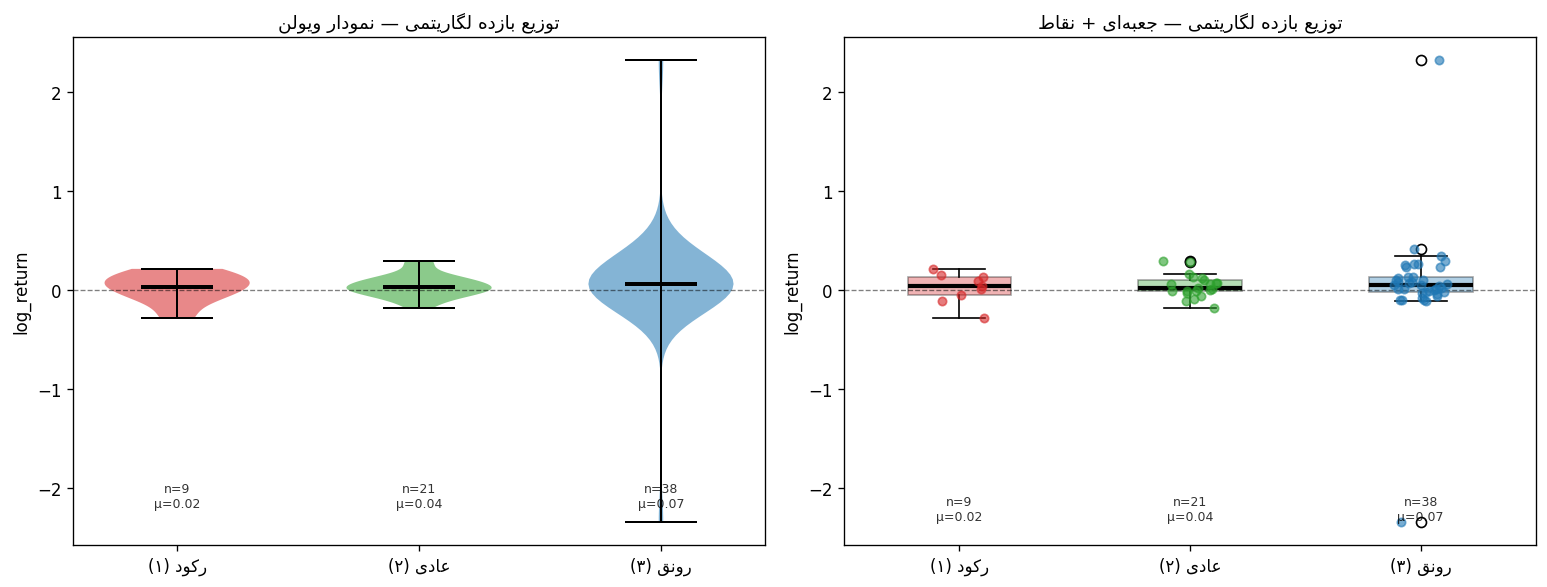

✓ نمودار ۱ ذخیره شد


In [3]:
# نمودار ۱ — violin + boxplot ترکیبی
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cycle_data   = [train_fe[train_fe["cycle"]==c]["log_return"].values for c in [1,2,3]]
cycle_colors = ["#d62728", "#2ca02c", "#1f77b4"]
cycle_labels = [fp("رکود (۱)"), fp("عادی (۲)"), fp("رونق (۳)")]

# Violin
vp = axes[0].violinplot(cycle_data, positions=[1,2,3],
                         showmeans=True, showmedians=True, widths=0.6)
for pc, col in zip(vp["bodies"], cycle_colors):
    pc.set_facecolor(col); pc.set_alpha(0.55)
for part in ["cmeans","cmedians","cbars","cmins","cmaxes"]:
    if part in vp:
        vp[part].set_color("black"); vp[part].set_linewidth(1.2)
axes[0].set_xticks([1,2,3]); axes[0].set_xticklabels(cycle_labels)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[0].set_title(fp("توزیع بازده لگاریتمی — نمودار ویولن"), fontsize=11)
axes[0].set_ylabel(fp("log_return"))

# Box + strip
bp = axes[1].boxplot(cycle_data, positions=[1,2,3], widths=0.45, patch_artist=True,
                      medianprops=dict(color="black", linewidth=2.5),
                      boxprops=dict(alpha=0.35))
for patch, col in zip(bp["boxes"], cycle_colors):
    patch.set_facecolor(col)
for c_val, x_pos, col in zip([1,2,3],[1,2,3],cycle_colors):
    yd = train_fe[train_fe["cycle"]==c_val]["log_return"].values
    axes[1].scatter(np.full(len(yd), x_pos) + np.random.uniform(-0.12,0.12,len(yd)),
                    yd, color=col, s=25, alpha=0.6, zorder=3)
axes[1].set_xticks([1,2,3]); axes[1].set_xticklabels(cycle_labels)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].set_title(fp("توزیع بازده لگاریتمی — جعبه‌ای + نقاط"), fontsize=11)
axes[1].set_ylabel(fp("log_return"))

# آمار توصیفی
for ax_idx, ax_ in enumerate(axes):
    for c_idx, (cd, xp) in enumerate(zip(cycle_data, [1,2,3])):
        ax_.text(xp, ax_.get_ylim()[0]*0.85 if ax_idx==0 else min(ax_.get_ylim()[0]*0.9,-0.3),
                 f"n={len(cd)}\nμ={np.mean(cd):.2f}",
                 ha="center", fontsize=7.5, alpha=0.8)

plt.tight_layout()
os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/01_logreturn_by_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۱ ذخیره شد")

## ۴. اعتبارسنجی متقاطع زمانی (TimeSeriesSplit)

برای داده سری زمانی **نمی‌توان** از K-Fold معمولی استفاده کرد.
`TimeSeriesSplit` تضمین می‌کند که fold اعتبارسنجی همیشه **بعد از** fold آموزش باشد.

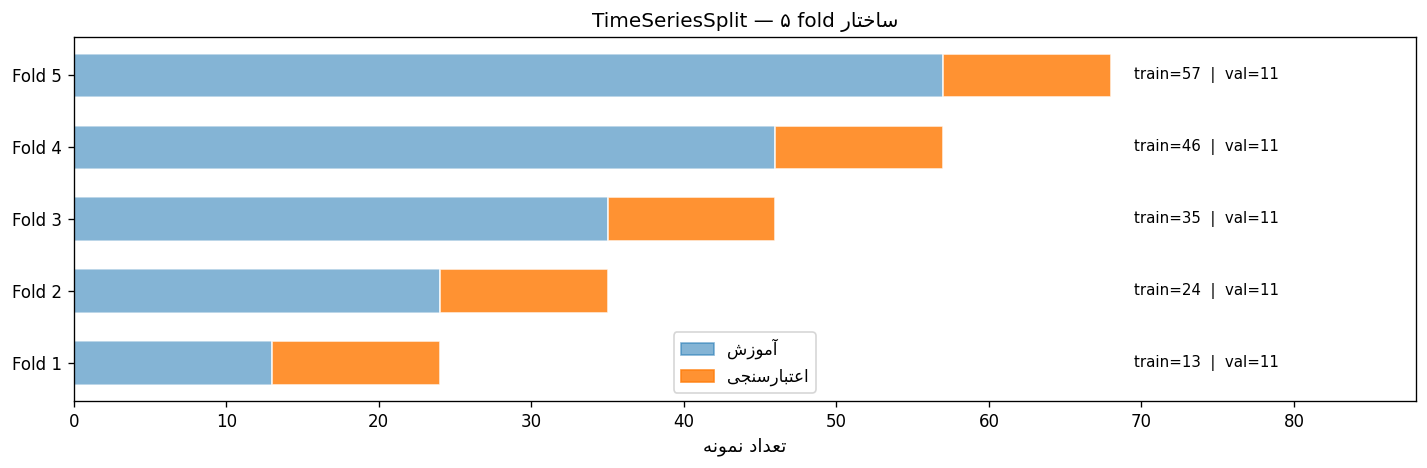

✓ نمودار ۲ ذخیره شد


In [4]:
# نمودار ۲ — نمایش بصری splits
tscv = TimeSeriesSplit(n_splits=5)
n = len(X_train)

fig, ax = plt.subplots(figsize=(12, 4))
fold_info = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    ax.barh(fold, len(tr_idx), left=0,
            color="#1f77b4", alpha=0.55, height=0.6, edgecolor="white")
    ax.barh(fold, len(val_idx), left=len(tr_idx),
            color="#ff7f0e", alpha=0.85, height=0.6, edgecolor="white")
    ax.text(n + 1.5, fold,
            f"train={len(tr_idx)}  |  val={len(val_idx)}",
            va="center", fontsize=9)
    fold_info.append((len(tr_idx), len(val_idx)))

ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)], fontsize=10)
ax.set_xlabel(fp("تعداد نمونه"), fontsize=11)
ax.set_title(fp("ساختار TimeSeriesSplit — ۵ fold"), fontsize=12)
ax.set_xlim(0, n + 20)
ax.legend(handles=[
    mpatches.Patch(color="#1f77b4", alpha=0.55, label=fp("آموزش")),
    mpatches.Patch(color="#ff7f0e", alpha=0.85, label=fp("اعتبارسنجی"))
])
plt.tight_layout()
plt.savefig("../results/figures/01_cv_splits.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۲ ذخیره شد")

## ۵. بهینه‌سازی هایپرپارامترها (RandomizedSearchCV)

جستجوی تصادفی روی ۴۰ ترکیب مختلف با اعتبارسنجی زمانی.

In [5]:
param_dist = {
    "max_depth":        randint(3, 7),
    "learning_rate":    uniform(0.03, 0.18),
    "n_estimators":     randint(100, 400),
    "subsample":        uniform(0.65, 0.35),
    "colsample_bytree": uniform(0.65, 0.35),
    "min_child_weight": randint(1, 5),
    "gamma":            uniform(0, 0.3),
    "reg_alpha":        uniform(0, 0.5),
    "reg_lambda":       uniform(0.5, 1.5),
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=0
)
search.fit(X_train, y_train)
best_params = search.best_params_

print(f"✓ بهترین RMSE اعتبارسنجی: {-search.best_score_:.5f}")
print("\nبهترین هایپرپارامترها:")
for k, v in sorted(best_params.items()):
    print(f"  {k:25s}: {v:.4f}" if isinstance(v, float) else f"  {k:25s}: {v}")

✓ بهترین RMSE اعتبارسنجی: 0.29428

بهترین هایپرپارامترها:
  colsample_bytree         : 0.8641
  gamma                    : 0.0021
  learning_rate            : 0.0342
  max_depth                : 5
  min_child_weight         : 3
  n_estimators             : 269
  reg_alpha                : 0.0233
  reg_lambda               : 1.9606
  subsample                : 0.7315


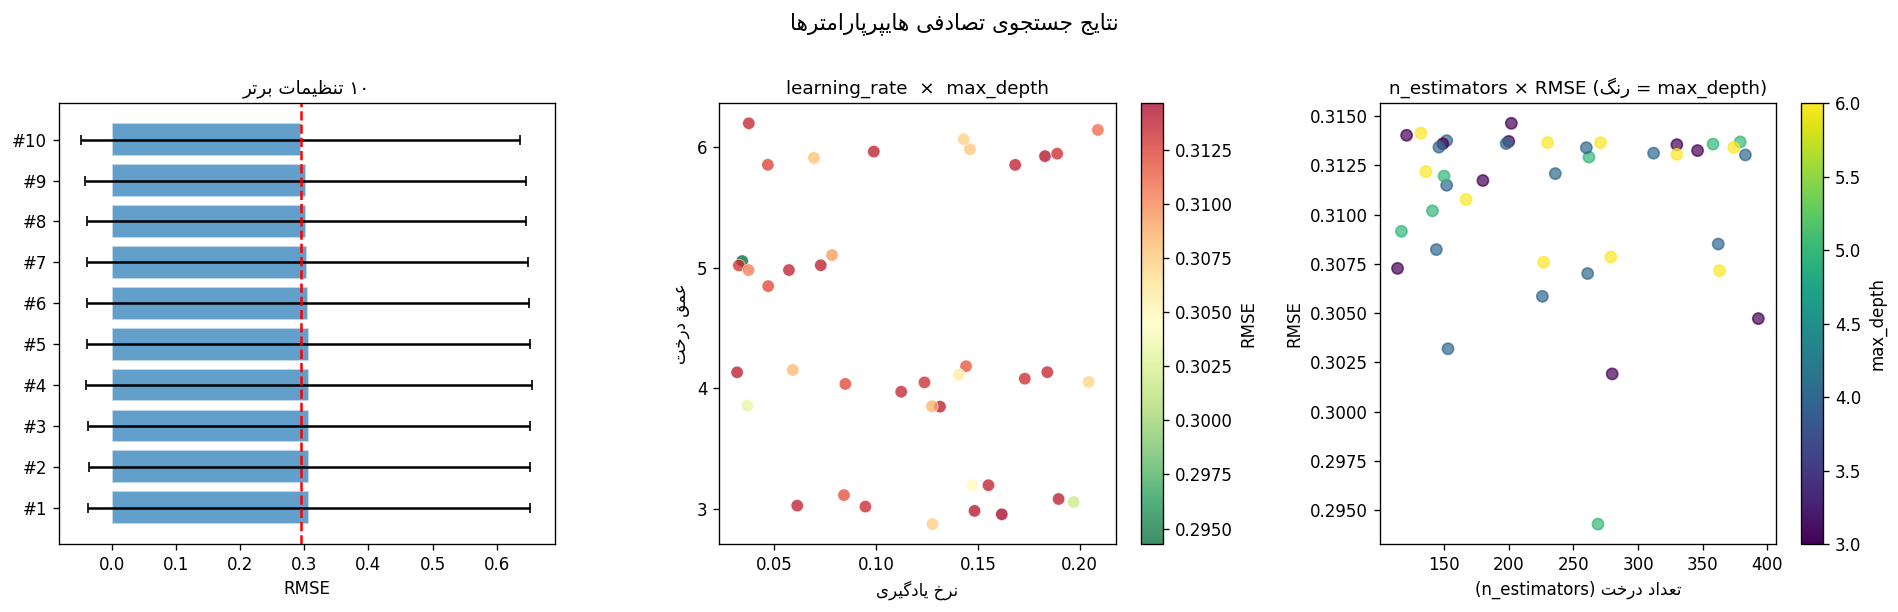

✓ نمودار ۳ ذخیره شد


In [6]:
# نمودار ۳ — نتایج جستجو
cv_res = pd.DataFrame(search.cv_results_)
cv_res["rmse"] = -cv_res["mean_test_score"]
cv_res_sorted  = cv_res.sort_values("rmse")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Top-10 configs
top10 = cv_res_sorted.head(10).reset_index(drop=True)
axes[0].barh(range(10), top10["rmse"][::-1].values,
             xerr=top10["std_test_score"][::-1].values,
             color="#1f77b4", alpha=0.7, edgecolor="white", capsize=3)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([f"#{i+1}" for i in range(10)])
axes[0].set_xlabel("RMSE")
axes[0].set_title(fp("۱۰ تنظیمات برتر"), fontsize=11)
axes[0].axvline(top10["rmse"].min(), color="red", linestyle="--", linewidth=1.5)

# ── learning_rate vs max_depth scatter
sc = axes[1].scatter(
    cv_res["param_learning_rate"].astype(float),
    cv_res["param_max_depth"].astype(int) + np.random.uniform(-0.2, 0.2, len(cv_res)),
    c=cv_res["rmse"], cmap="RdYlGn_r", s=55, alpha=0.75, edgecolors="white", linewidths=0.4
)
plt.colorbar(sc, ax=axes[1], label="RMSE")
axes[1].set_xlabel(fp("نرخ یادگیری"))
axes[1].set_ylabel(fp("عمق درخت"))
axes[1].set_title(fp("learning_rate  ×  max_depth"), fontsize=11)
axes[1].set_yticks([3,4,5,6])

# ── n_estimators vs RMSE
axes[2].scatter(
    cv_res["param_n_estimators"].astype(int),
    cv_res["rmse"],
    c=cv_res["param_max_depth"].astype(int), cmap="viridis", s=45, alpha=0.7
)
axes[2].set_xlabel(fp("تعداد درخت (n_estimators)"))
axes[2].set_ylabel("RMSE")
axes[2].set_title(fp("n_estimators × RMSE (رنگ = max_depth)"), fontsize=11)
sm2 = plt.cm.ScalarMappable(cmap="viridis",
        norm=plt.Normalize(cv_res["param_max_depth"].astype(int).min(),
                           cv_res["param_max_depth"].astype(int).max()))
plt.colorbar(sm2, ax=axes[2], label="max_depth")

plt.suptitle(fp("نتایج جستجوی تصادفی هایپرپارامترها"), fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../results/figures/01_hyperparam_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۳ ذخیره شد")

## ۶. آموزش مدل نهایی و منحنی یادگیری

مدل نهایی با بهترین هایپرپارامترها روی **کل داده آموزش** ترین می‌شود.
برای رسم learning curve، آخرین ۱۵٪ داده آموزش به عنوان validation موقت استفاده می‌شود.

In [7]:
# ── Learning curve data (train با eval_set موقت)
n_lc_val = max(8, int(0.15 * len(X_train)))
lc_model = xgb.XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42
)
lc_model.fit(
    X_train[:-n_lc_val], y_train[:-n_lc_val],
    eval_set=[
        (X_train[:-n_lc_val], y_train[:-n_lc_val]),
        (X_train[-n_lc_val:], y_train[-n_lc_val:])
    ],
    verbose=False
)
lc_results = lc_model.evals_result()
train_rmse = lc_results["validation_0"]["rmse"]
val_rmse   = lc_results["validation_1"]["rmse"]

# ── مدل نهایی روی کل train
best_model = xgb.XGBRegressor(**best_params, objective="reg:squarederror", random_state=42)
best_model.fit(X_train, y_train)
print(f"✓ مدل نهایی آموزش دید ({len(X_train)} نمونه)")

✓ مدل نهایی آموزش دید (68 نمونه)


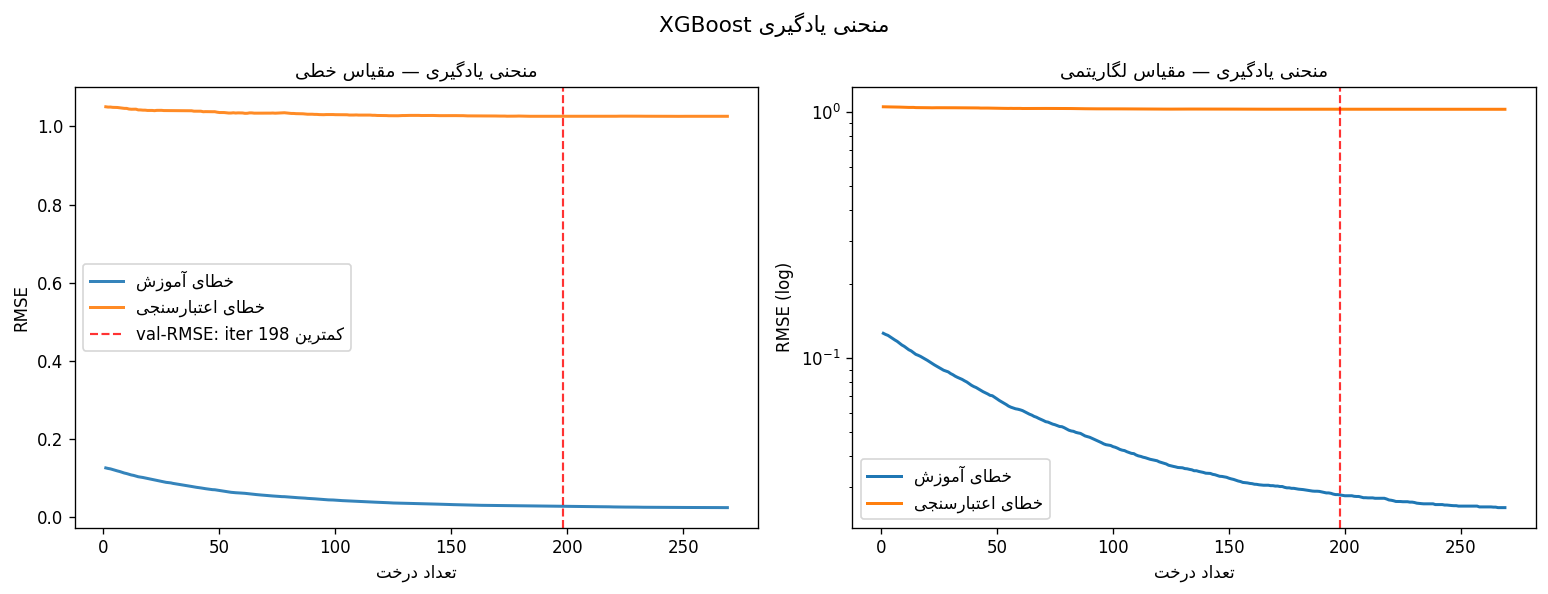

✓ نمودار ۴ ذخیره شد


In [8]:
# نمودار ۴ — منحنی یادگیری
iters       = range(1, len(train_rmse) + 1)
best_iter   = int(np.argmin(val_rmse)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# مقیاس خطی
axes[0].plot(iters, train_rmse, label=fp("خطای آموزش"),
             color="#1f77b4", linewidth=1.8, alpha=0.9)
axes[0].plot(iters, val_rmse,   label=fp("خطای اعتبارسنجی"),
             color="#ff7f0e", linewidth=1.8, alpha=0.9)
axes[0].axvline(best_iter, color="red", linestyle="--", linewidth=1.3, alpha=0.8,
                label=fp(f"کمترین val-RMSE: iter {best_iter}"))
axes[0].set_title(fp("منحنی یادگیری — مقیاس خطی"), fontsize=11)
axes[0].set_xlabel(fp("تعداد درخت"))
axes[0].set_ylabel("RMSE")
axes[0].legend()

# مقیاس لگاریتمی (تفاوت‌ها واضح‌تر)
axes[1].semilogy(iters, train_rmse, color="#1f77b4", linewidth=1.8,
                 label=fp("خطای آموزش"))
axes[1].semilogy(iters, val_rmse,   color="#ff7f0e", linewidth=1.8,
                 label=fp("خطای اعتبارسنجی"))
axes[1].axvline(best_iter, color="red", linestyle="--", linewidth=1.3, alpha=0.8)
axes[1].set_title(fp("منحنی یادگیری — مقیاس لگاریتمی"), fontsize=11)
axes[1].set_xlabel(fp("تعداد درخت"))
axes[1].set_ylabel("RMSE (log)")
axes[1].legend()

plt.suptitle(fp("منحنی یادگیری XGBoost"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/01_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۴ ذخیره شد")

## ۷. اهمیت ویژگی‌ها

### ۷-۱. Feature Importance داخلی XGBoost (معیار Gain)
**Gain** = میانگین کاهش impurity در تمام split هایی که از این ویژگی استفاده کرده‌اند.

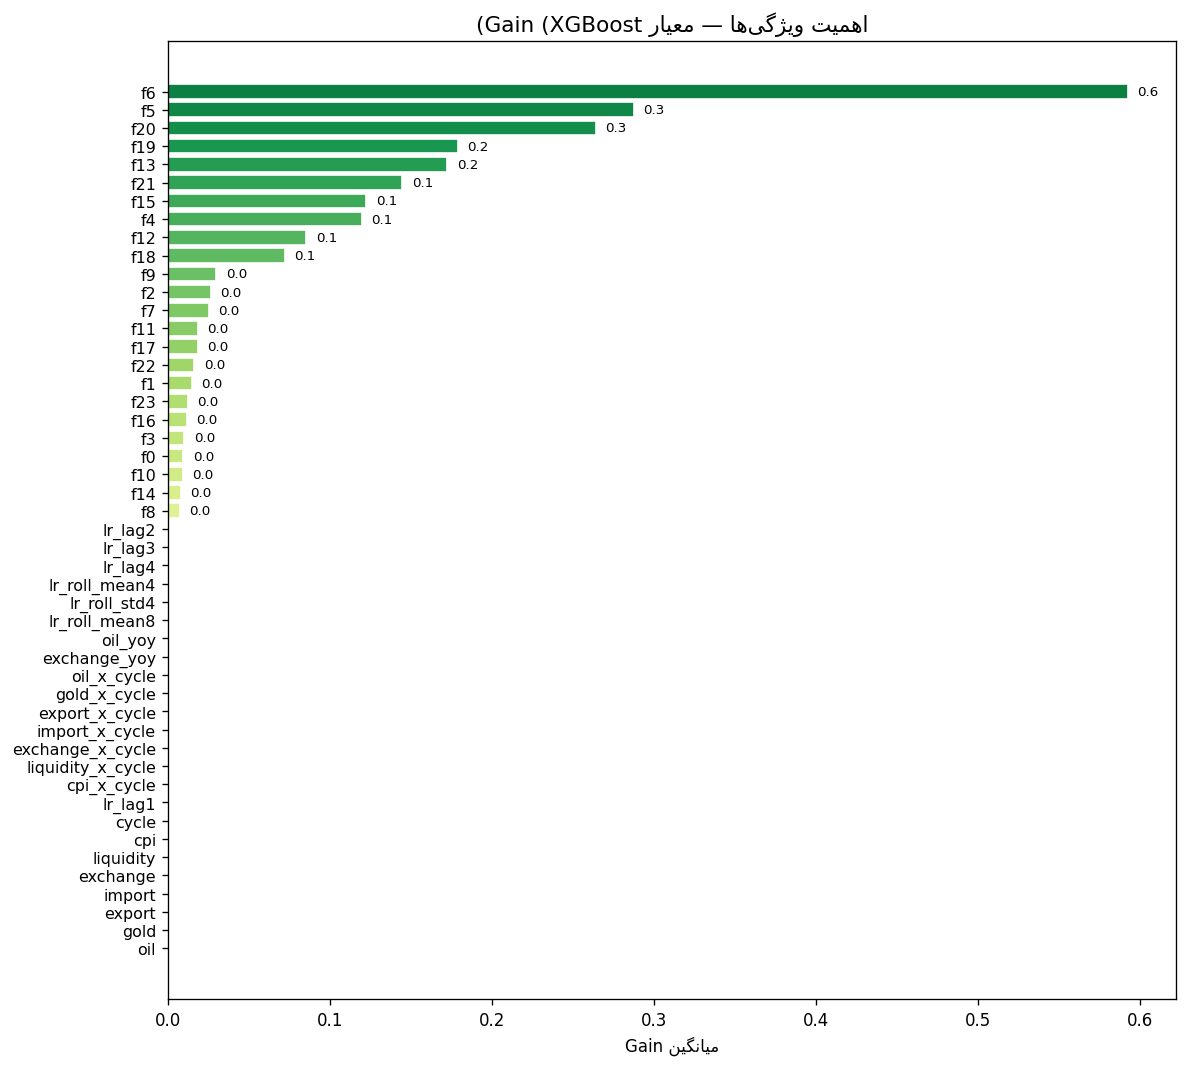

✓ نمودار ۵ ذخیره شد


In [9]:
# نمودار ۵ — Feature Importance (Gain)
imp_dict  = best_model.get_booster().get_score(importance_type="gain")
# اضافه کردن ویژگی‌های با امتیاز صفر
for f in FEAT_COLS:
    if f not in imp_dict:
        imp_dict[f] = 0
imp_df = pd.DataFrame({"feature": list(imp_dict.keys()),
                        "gain":    list(imp_dict.values())})             .sort_values("gain", ascending=True)

palette = plt.cm.RdYlGn(np.linspace(0.2, 0.95, len(imp_df)))
fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(range(len(imp_df)), imp_df["gain"], color=palette, edgecolor="white")
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df["feature"], fontsize=9.5)
ax.set_title(fp("اهمیت ویژگی‌ها — معیار Gain (XGBoost)"), fontsize=13)
ax.set_xlabel(fp("Gain میانگین"))
for bar, val in zip(bars, imp_df["gain"]):
    if val > 0:
        ax.text(val + max(imp_df["gain"]) * 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../results/figures/01_feature_importance_gain.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۵ ذخیره شد")

### ۷-۲. SHAP Beeswarm Plot
SHAP (SHapley Additive exPlanations) نشان می‌دهد هر ویژگی **در چه جهتی** و **به چه میزان** پیش‌بینی را تغییر می‌دهد.
- محور افقی: مقدار SHAP (اثر روی خروجی)
- رنگ نقطه: مقدار ویژگی (قرمز = زیاد، آبی = کم)

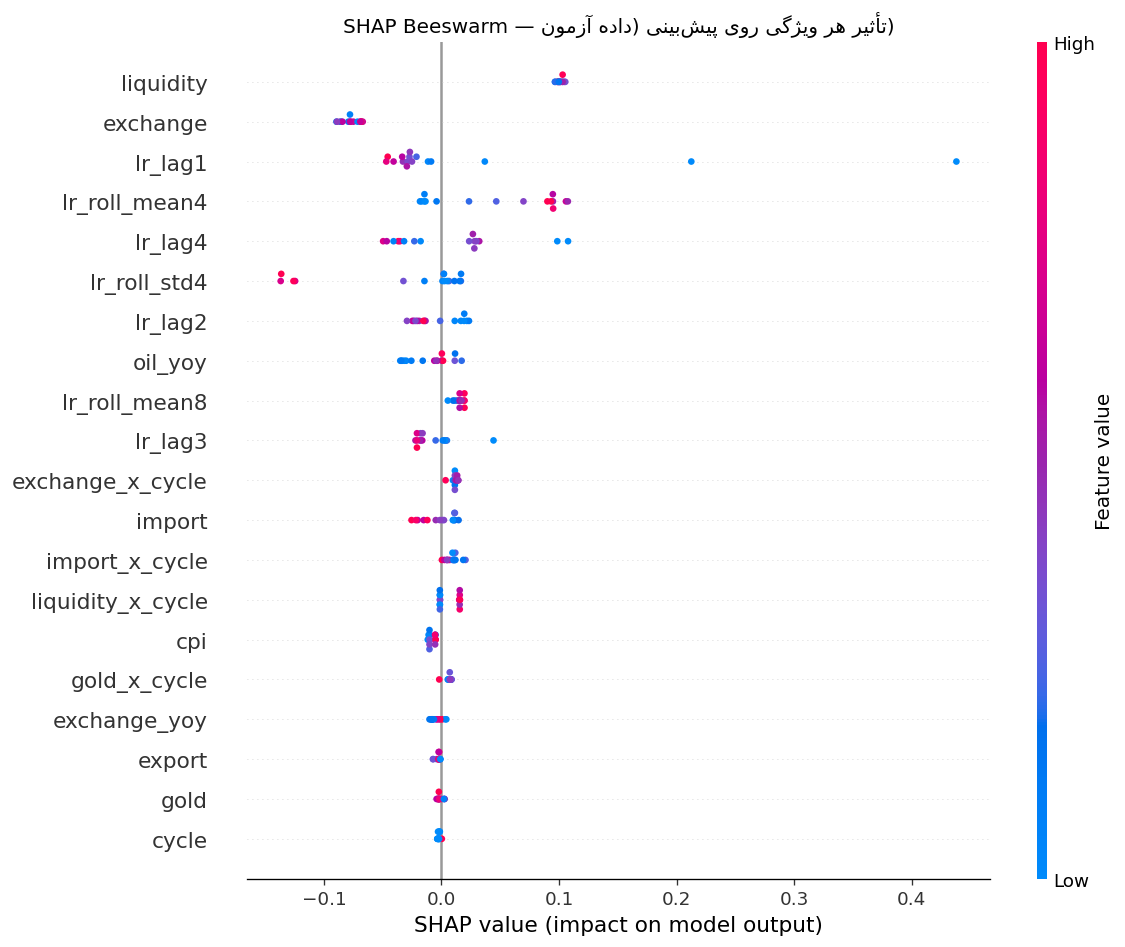

✓ نمودار ۶ ذخیره شد


In [10]:
# نمودار ۶ — SHAP Beeswarm
explainer       = shap.TreeExplainer(best_model)
X_test_df       = pd.DataFrame(X_test, columns=FEAT_COLS)
shap_values_arr = explainer.shap_values(X_test_df)
expected_val    = explainer.expected_value

shap.summary_plot(shap_values_arr, X_test_df, show=False, plot_size=None)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.title(fp("SHAP Beeswarm — تأثیر هر ویژگی روی پیش‌بینی (داده آزمون)"), fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/01_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۶ ذخیره شد")

### ۷-۳. SHAP Waterfall — تفسیر تک‌پیش‌بینی

نمودار waterfall نشان می‌دهد چرا مدل برای یک فصل خاص این عدد را پیش‌بینی کرده.
هر بار نشان می‌دهد چه ویژگی‌هایی پیش‌بینی را بالا یا پایین بردند.

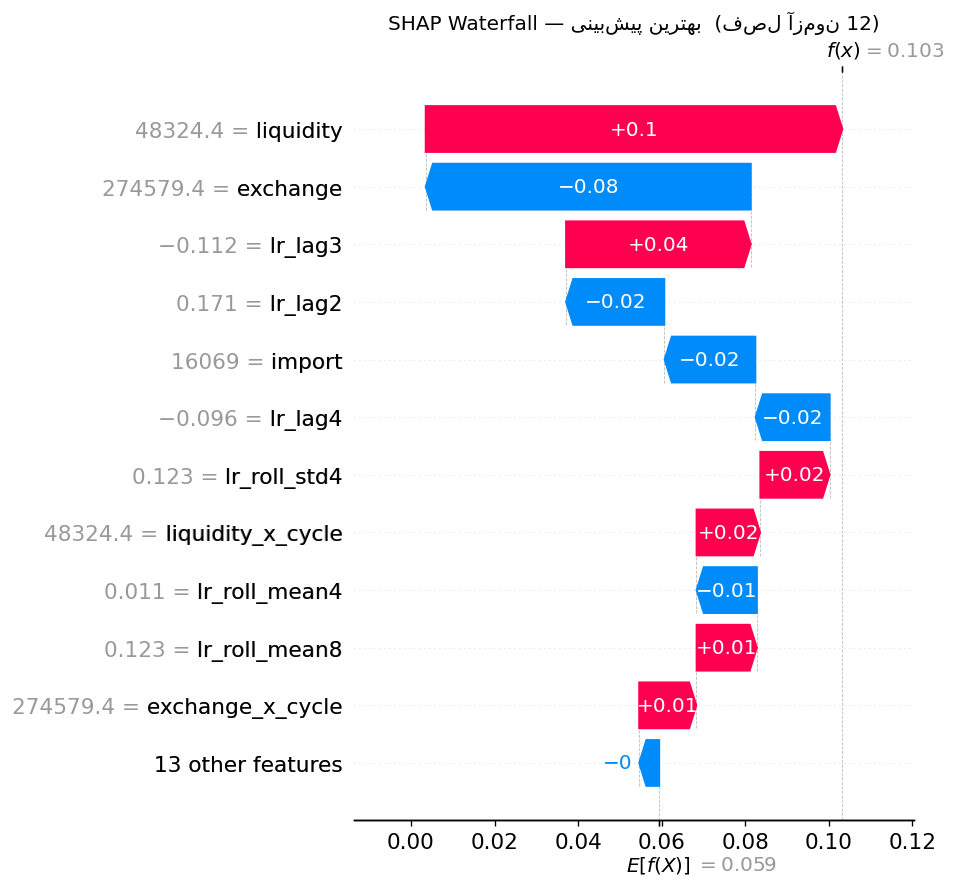

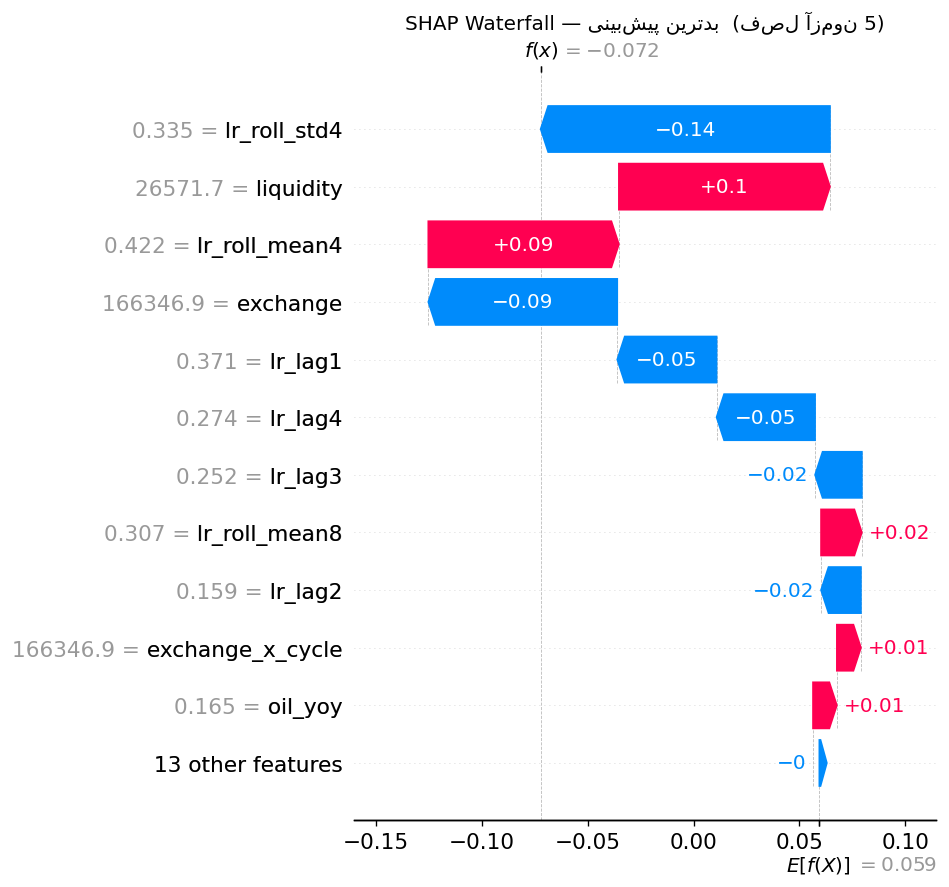

✓ نمودارهای ۷ (best + worst) ذخیره شدند


In [11]:
# نمودار ۷ — SHAP Waterfall
shap_exp = shap.Explanation(
    values=shap_values_arr,
    base_values=np.full(len(X_test_df), expected_val),
    data=X_test_df.values,
    feature_names=FEAT_COLS
)

y_pred_tmp = best_model.predict(X_test)
worst_idx  = int(np.argmax(np.abs(y_test - y_pred_tmp)))
best_idx   = int(np.argmin(np.abs(y_test - y_pred_tmp)))

for idx, label_fa in [(best_idx, fp("بهترین پیش‌بینی")),
                       (worst_idx, fp("بدترین پیش‌بینی"))]:
    plt.figure(figsize=(11, 6))
    shap.plots.waterfall(shap_exp[idx], max_display=12, show=False)
    plt.title(f"SHAP Waterfall — {label_fa}  (فصل آزمون {idx+1})", fontsize=12)
    plt.tight_layout()
    tag = "best" if idx == best_idx else "worst"
    plt.savefig(f"../results/figures/01_shap_waterfall_{tag}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("✓ نمودارهای ۷ (best + worst) ذخیره شدند")

## ۸. پیش‌بینی روی داده آزمون

### ۸-۱. بازسازی قیمت از log_return

مدل `log_return` را پیش‌بینی می‌کند.
برای مقایسه با قیمت واقعی، از فرمول زیر استفاده می‌کنیم:

$$\text{log\_price}[t] = \text{log\_price}[t-1] + \widehat{\text{log\_return}}[t]$$
$$\text{price}[t] = e^{\text{log\_price}[t]}$$

In [12]:
y_pred_lr = best_model.predict(X_test)

# بازسازی سطح قیمت
last_log_price = train_fe["log_stock_price"].iloc[-1]
log_prices     = np.zeros(len(y_pred_lr))
log_prices[0]  = last_log_price + y_pred_lr[0]
for i in range(1, len(y_pred_lr)):
    log_prices[i] = log_prices[i-1] + y_pred_lr[i]

y_pred_price = np.exp(log_prices)
y_true_price = test_fe["stock_price"].values
test_dates   = test_fe.index.to_timestamp()

# جدول نتایج
result_df = pd.DataFrame({
    "دوره":         test_fe.index.astype(str),
    "واقعی":        y_true_price.astype(int),
    "پیش‌بینی":     y_pred_price.astype(int),
    "خطا (%)":      np.round((y_pred_price - y_true_price)/y_true_price*100, 2),
    "چرخه":         test_fe["cycle"].values.astype(int)
})
print(result_df.to_string(index=False))

  دوره   واقعی  پیش‌بینی  خطا (%)  چرخه
2019Q1  234879    210285   -10.47     3
2019Q2  302104    220853   -26.89     1
2019Q3  353997    239490   -32.35     1
2019Q4  512901    273934   -46.59     1
2020Q1 1270627    254832   -79.94     1
2020Q2 1595160    262930   -83.52     1
2020Q3 1439124    276501   -80.79     1
2020Q4 1307707    282191   -78.42     1
2021Q1 1168665    303391   -74.04     1
2021Q2 1386451    441018   -68.19     1
2021Q3 1318360    543501   -58.77     1
2021Q4 1367250    602623   -55.92     1
2022Q1 1539632    749540   -51.32     1
2022Q2 1355241    783783   -42.17     1
2022Q3 1496201   1243131   -16.91     1
2022Q4 1960457   1434055   -26.85     1


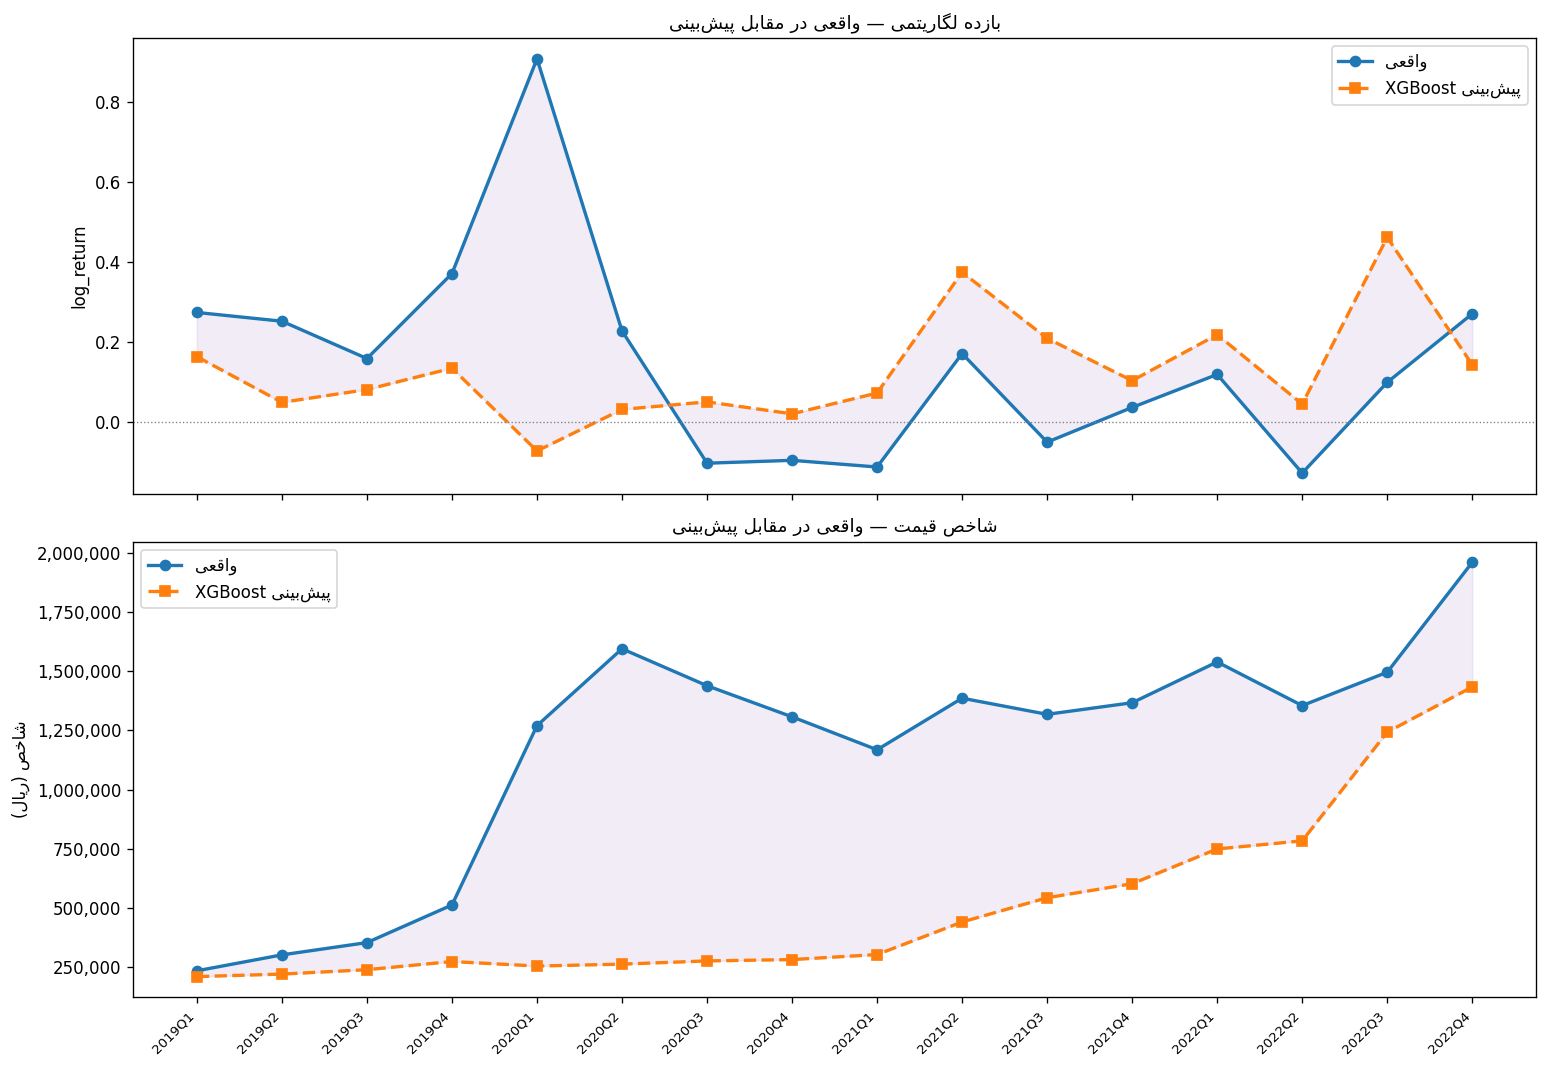

✓ نمودار ۸ ذخیره شد


In [13]:
# نمودار ۸ — واقعی vs پیش‌بینی (log_return و قیمت)
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
x_ticks = range(len(test_dates))

# ── log_return
axes[0].plot(x_ticks, y_test,    color="#1f77b4", marker="o", ms=6,
             linewidth=2, label=fp("واقعی"))
axes[0].plot(x_ticks, y_pred_lr, color="#ff7f0e", marker="s", ms=6,
             linewidth=2, linestyle="--", label=fp("پیش‌بینی XGBoost"))
axes[0].fill_between(x_ticks, y_test, y_pred_lr, alpha=0.12, color="#9467bd")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0].set_title(fp("بازده لگاریتمی — واقعی در مقابل پیش‌بینی"), fontsize=11)
axes[0].set_ylabel(fp("log_return"))
axes[0].legend()

# ── قیمت
axes[1].plot(x_ticks, y_true_price, color="#1f77b4", marker="o", ms=6,
             linewidth=2, label=fp("واقعی"))
axes[1].plot(x_ticks, y_pred_price, color="#ff7f0e", marker="s", ms=6,
             linewidth=2, linestyle="--", label=fp("پیش‌بینی XGBoost"))
axes[1].fill_between(x_ticks, y_true_price, y_pred_price, alpha=0.12, color="#9467bd")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
axes[1].set_title(fp("شاخص قیمت — واقعی در مقابل پیش‌بینی"), fontsize=11)
axes[1].set_ylabel(fp("شاخص (ریال)"))
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels(test_fe.index.astype(str), rotation=45, ha="right", fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/01_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۸ ذخیره شد")

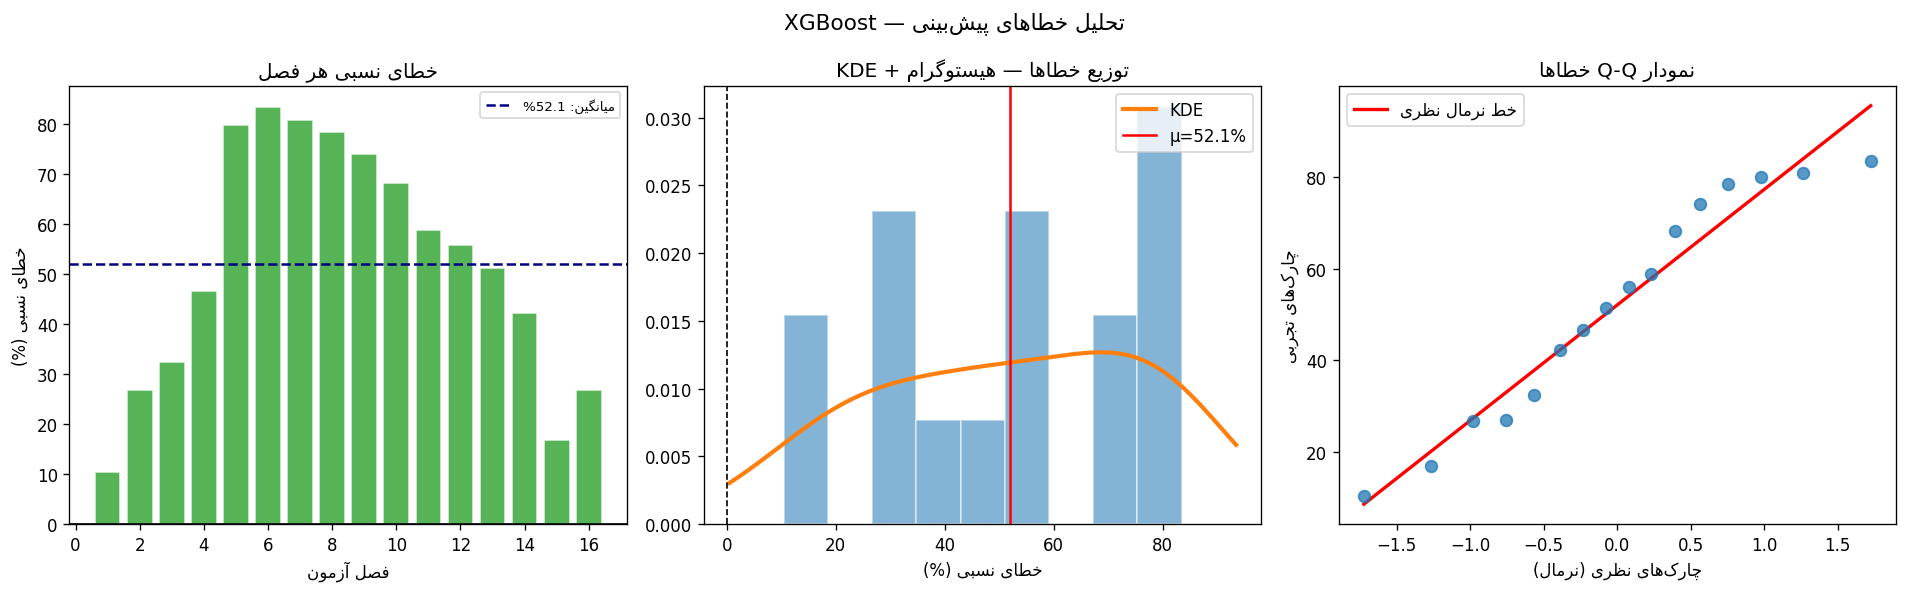

✓ نمودار ۹ ذخیره شد


In [14]:
# نمودار ۹ — تحلیل خطاها (۳ نمودار در یک ردیف)
residuals     = y_true_price - y_pred_price
residuals_pct = residuals / y_true_price * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── ۱. Bar chart خطای نسبی
bar_colors = ["#2ca02c" if r > 0 else "#d62728" for r in residuals_pct]
axes[0].bar(range(1, len(residuals_pct)+1), residuals_pct,
            color=bar_colors, alpha=0.8, edgecolor="white")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhline(np.mean(residuals_pct), color="navy", linewidth=1.5, linestyle="--",
                label=fp(f"میانگین: {np.mean(residuals_pct):.1f}%"))
axes[0].set_xlabel(fp("فصل آزمون"))
axes[0].set_ylabel(fp("خطای نسبی (%)"))
axes[0].set_title(fp("خطای نسبی هر فصل"))
axes[0].legend(fontsize=8)

# ── ۲. Histogram + KDE
axes[1].hist(residuals_pct, bins=9, color="#1f77b4", alpha=0.55,
             edgecolor="white", density=True)
x_kde = np.linspace(residuals_pct.min()-10, residuals_pct.max()+10, 300)
kde   = gaussian_kde(residuals_pct)
axes[1].plot(x_kde, kde(x_kde), color="#ff7f0e", linewidth=2.5, label="KDE")
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].axvline(np.mean(residuals_pct), color="red", linewidth=1.5,
                label=fp(f"μ={np.mean(residuals_pct):.1f}%"))
axes[1].set_title(fp("توزیع خطاها — هیستوگرام + KDE"))
axes[1].set_xlabel(fp("خطای نسبی (%)"))
axes[1].legend()

# ── ۳. Q-Q plot
(osm, osr), (slope, intercept, _) = probplot(residuals_pct, dist="norm")
axes[2].scatter(osm, osr, color="#1f77b4", alpha=0.75, s=50, zorder=3)
x_line = np.array([min(osm), max(osm)])
axes[2].plot(x_line, slope*x_line + intercept, color="red", linewidth=2,
             label=fp("خط نرمال نظری"))
axes[2].set_title(fp("نمودار Q-Q خطاها"))
axes[2].set_xlabel(fp("چارک‌های نظری (نرمال)"))
axes[2].set_ylabel(fp("چارک‌های تجربی"))
axes[2].legend()

plt.suptitle(fp("تحلیل خطاهای پیش‌بینی — XGBoost"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/01_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۹ ذخیره شد")

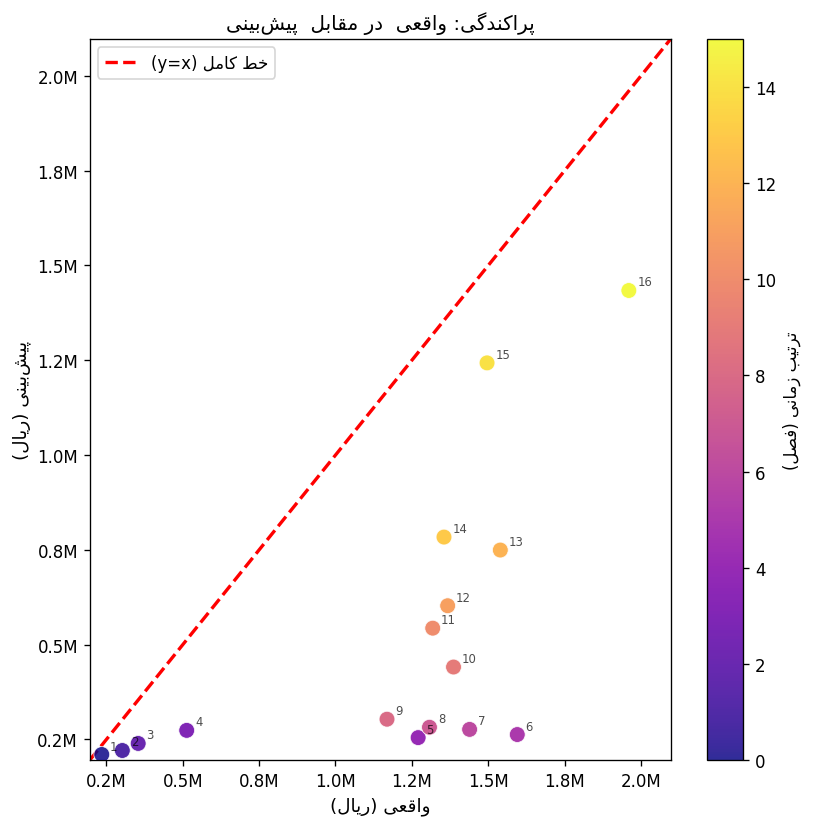

✓ نمودار ۱۰ ذخیره شد


In [15]:
# نمودار ۱۰ — Scatter: واقعی vs پیش‌بینی
fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(y_true_price, y_pred_price,
                c=range(len(y_true_price)), cmap="plasma",
                s=90, alpha=0.85, edgecolors="white", linewidths=0.5, zorder=3)

# خط کامل (y = x)
lim_min = min(y_true_price.min(), y_pred_price.min()) * 0.93
lim_max = max(y_true_price.max(), y_pred_price.max()) * 1.07
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        "r--", linewidth=2, label=fp("خط کامل (y=x)"), zorder=2)

# شماره‌گذاری نقاط
for i, (xt, xp) in enumerate(zip(y_true_price, y_pred_price)):
    ax.annotate(str(i+1), (xt, xp), textcoords="offset points",
                xytext=(5, 3), fontsize=7, alpha=0.7)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel(fp("واقعی (ریال)"), fontsize=11)
ax.set_ylabel(fp("پیش‌بینی (ریال)"), fontsize=11)
ax.set_title(fp("پراکندگی: واقعی  در مقابل  پیش‌بینی"), fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.legend()
plt.colorbar(sc, ax=ax, label=fp("ترتیب زمانی (فصل)"))
plt.tight_layout()
plt.savefig("../results/figures/01_scatter_true_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۰ ذخیره شد")

## ۹. عملکرد مدل به تفکیک رژیم اقتصادی

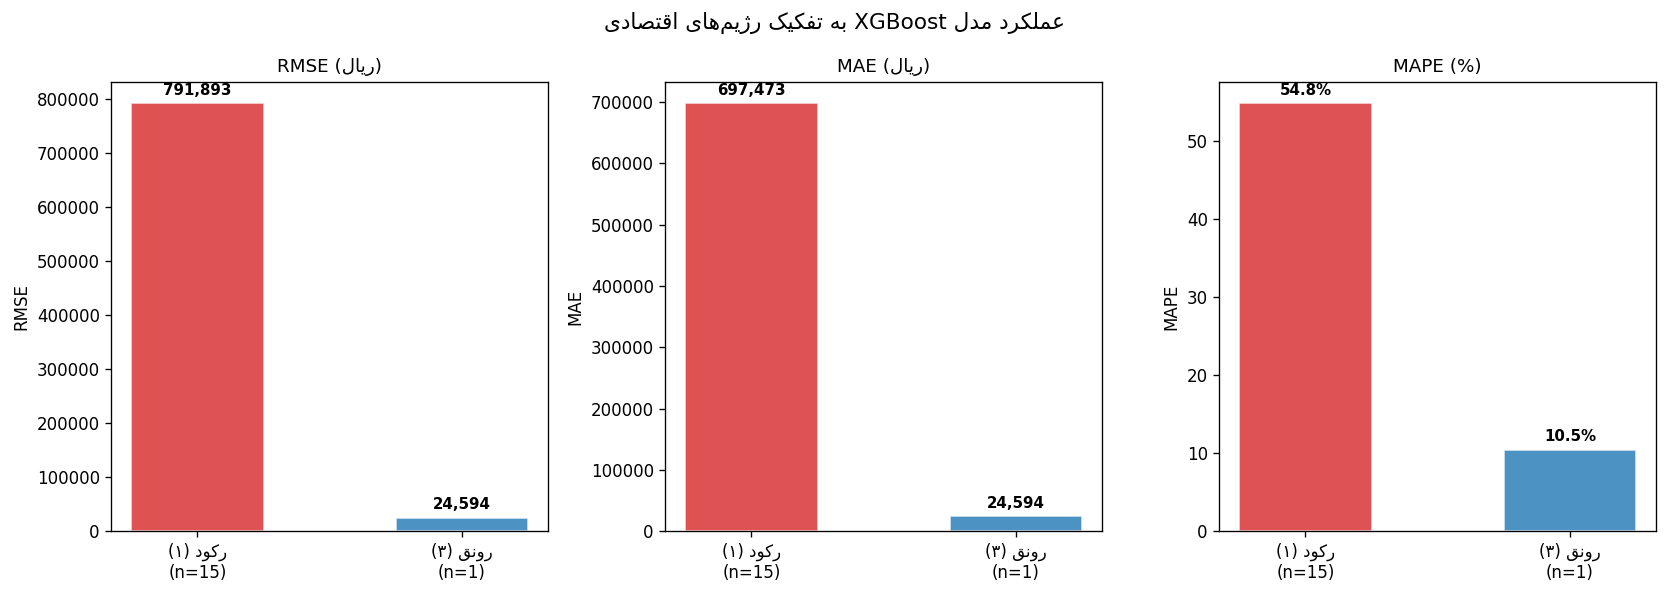


    چرخه    n         RMSE          MAE     MAPE
--------------------------------------------------
       1   15      791,893      697,473    54.8%
       3    1       24,594       24,594    10.5%
✓ نمودار ۱۱ ذخیره شد


In [16]:
# نمودار ۱۱ — عملکرد به تفکیک چرخه
cycle_metrics = {}
for c in sorted(test_fe["cycle"].unique()):
    mask = test_fe["cycle"].values == c
    if mask.sum() == 0:
        continue
    yt, yp = y_true_price[mask], y_pred_price[mask]
    cycle_metrics[int(c)] = {
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE":  mean_absolute_error(yt, yp),
        "MAPE": np.mean(np.abs((yt-yp)/yt)) * 100,
        "n":    mask.sum()
    }

cycle_names_fa = {1: fp("رکود (۱)"), 2: fp("عادی (۲)"), 3: fp("رونق (۳)")}
cycle_colors   = {1: "#d62728",      2: "#2ca02c",       3: "#1f77b4"}
keys           = sorted(cycle_metrics.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax_i, metric_name in enumerate(["RMSE", "MAE", "MAPE"]):
    vals   = [cycle_metrics[k][metric_name] for k in keys]
    labels = [f"{cycle_names_fa.get(k, k)}\n(n={cycle_metrics[k]['n']})" for k in keys]
    colors = [cycle_colors.get(k, "gray") for k in keys]
    bars   = axes[ax_i].bar(labels, vals, color=colors, alpha=0.8, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        fmt = f"{val:,.0f}" if metric_name != "MAPE" else f"{val:.1f}%"
        axes[ax_i].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height() + max(vals)*0.02,
                         fmt, ha="center", fontsize=9, fontweight="bold")
    unit = "%" if metric_name == "MAPE" else fp("ریال")
    axes[ax_i].set_title(f"{metric_name} ({unit})", fontsize=11)
    axes[ax_i].set_ylabel(metric_name)

plt.suptitle(fp("عملکرد مدل XGBoost به تفکیک رژیم‌های اقتصادی"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/01_performance_by_cycle.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'چرخه':>8} {'n':>4} {'RMSE':>12} {'MAE':>12} {'MAPE':>8}")
print("-" * 50)
for k in keys:
    m = cycle_metrics[k]
    print(f"  {k:6d} {m['n']:>4} {m['RMSE']:>12,.0f} {m['MAE']:>12,.0f} {m['MAPE']:>7.1f}%")
print("✓ نمودار ۱۱ ذخیره شد")

## ۱۰. معیارهای ارزیابی نهایی

In [17]:
RMSE = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
MAE  = mean_absolute_error(y_true_price, y_pred_price)
MAPE = np.mean(np.abs((y_true_price - y_pred_price) / y_true_price)) * 100
R2   = r2_score(y_true_price, y_pred_price)

metrics = {"model":"XGBoost", "RMSE":RMSE, "MAE":MAE, "MAPE":MAPE, "R2":R2}

print("╔══════════════════════════════════════╗")
print(f"║  {'مدل: XGBoost':^36} ║")
print("╠══════════════════════════════════════╣")
print(f"║  {'RMSE':<10} {RMSE:>23,.2f}  ║")
print(f"║  {'MAE':<10} {MAE:>23,.2f}  ║")
print(f"║  {'MAPE':<10} {MAPE:>22.2f}%  ║")
print(f"║  {'R²':<10} {R2:>24.4f}  ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║              مدل: XGBoost             ║
╠══════════════════════════════════════╣
║  RMSE                    766,771.65  ║
║  MAE                     655,418.06  ║
║  MAPE                        52.07%  ║
║  R²                          -1.3419  ║
╚══════════════════════════════════════╝


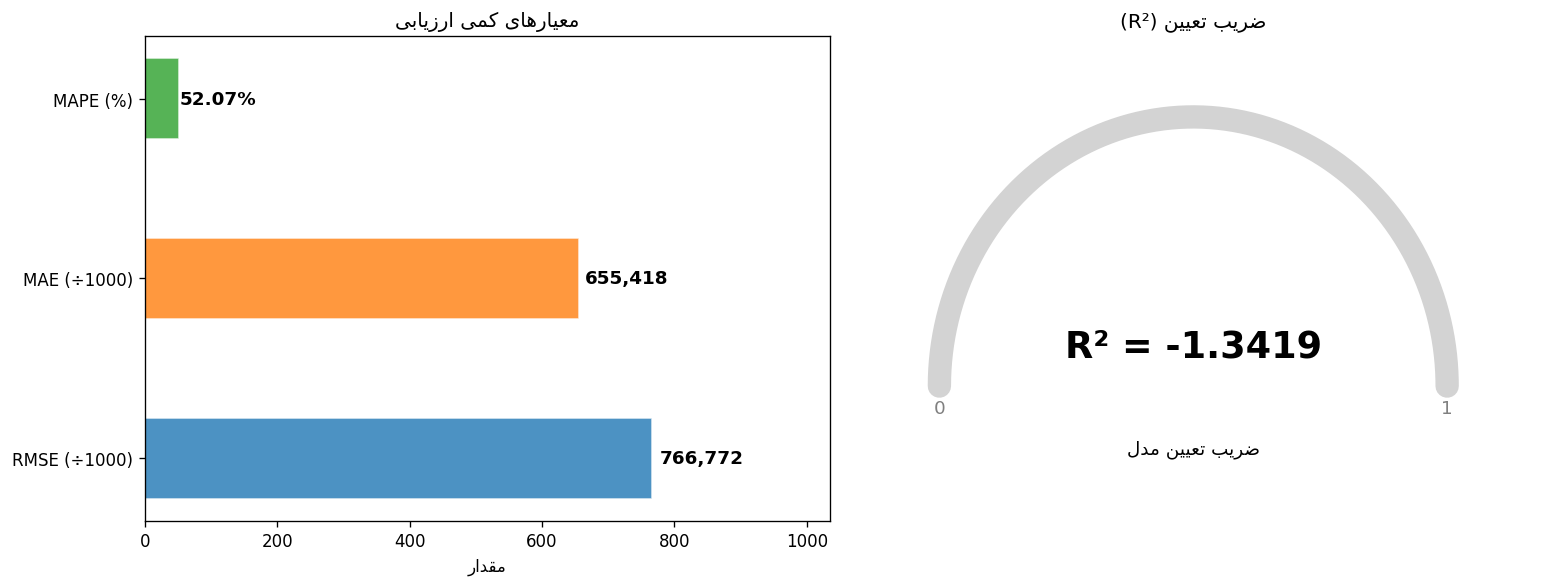

✓ نمودار ۱۲ ذخیره شد


In [18]:
# نمودار ۱۲ — خلاصه معیارها + R² gauge
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── جدول بصری RMSE / MAE / MAPE
metric_labels = ["RMSE (÷1000)", "MAE (÷1000)", "MAPE (%)"]
metric_vals   = [RMSE/1000, MAE/1000, MAPE]
m_colors      = ["#1f77b4", "#ff7f0e", "#2ca02c"]
bars          = axes[0].barh(metric_labels, metric_vals, color=m_colors,
                              alpha=0.8, edgecolor="white", height=0.45)
for bar, val, lbl in zip(bars, metric_vals, metric_labels):
    real_val = val*1000 if "÷1000" in lbl else val
    fmt = f"{real_val:,.0f}" if "÷1000" in lbl else f"{real_val:.2f}%"
    axes[0].text(bar.get_width()*1.015, bar.get_y()+bar.get_height()/2,
                 fmt, va="center", fontsize=11, fontweight="bold")
axes[0].set_title(fp("معیارهای کمی ارزیابی"), fontsize=12)
axes[0].set_xlabel(fp("مقدار"))
axes[0].set_xlim(0, max(metric_vals)*1.35)

# ── R² Gauge (نیم‌دایره)
theta_all  = np.linspace(np.pi, 0, 300)
r2_clipped = max(0, min(1, R2))
theta_fill = np.linspace(np.pi, np.pi*(1 - r2_clipped), 300)
gauge_color = "#2ca02c" if r2_clipped >= 0.7 else ("#ff7f0e" if r2_clipped >= 0.4 else "#d62728")
axes[1].plot(np.cos(theta_all), np.sin(theta_all), "lightgray", linewidth=14,
             solid_capstyle="round")
axes[1].plot(np.cos(theta_fill), np.sin(theta_fill), gauge_color, linewidth=14,
             solid_capstyle="round")
axes[1].text(0,  0.15, f"R² = {R2:.4f}", ha="center", va="center", fontsize=22, fontweight="bold")
axes[1].text(0, -0.25, fp("ضریب تعیین مدل"), ha="center", fontsize=11)
axes[1].text(-1, -0.1, "0", ha="center", fontsize=11, color="gray")
axes[1].text( 1, -0.1, "1", ha="center", fontsize=11, color="gray")
axes[1].set_xlim(-1.35, 1.35); axes[1].set_ylim(-0.5, 1.3); axes[1].axis("off")
axes[1].set_title(fp("ضریب تعیین (R²)"), fontsize=12)

plt.tight_layout()
plt.savefig("../results/figures/01_metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۲ ذخیره شد")

## ۱۱. ذخیره مدل و نتایج

In [19]:
os.makedirs("../models",          exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

# ذخیره مدل
joblib.dump(best_model, "../models/01_xgboost_model.pkl")

# ذخیره معیارها
pd.DataFrame([metrics]).to_csv("../results/metrics/01_xgboost_metrics.csv", index=False)

# ذخیره پیش‌بینی‌ها
result_df.to_csv("../results/metrics/01_xgboost_predictions.csv", index=False)

print("✓ مدل ذخیره شد:   ../models/01_xgboost_model.pkl")
print("✓ معیارها:         ../results/metrics/01_xgboost_metrics.csv")
print("✓ پیش‌بینی‌ها:      ../results/metrics/01_xgboost_predictions.csv")
print()
print("نمودارهای ذخیره‌شده این notebook:")
figs = sorted([f for f in os.listdir("../results/figures") if f.startswith("01_")])
for f in figs:
    print(f"  📊 {f}")

✓ مدل ذخیره شد:   ../models/01_xgboost_model.pkl
✓ معیارها:         ../results/metrics/01_xgboost_metrics.csv
✓ پیش‌بینی‌ها:      ../results/metrics/01_xgboost_predictions.csv

نمودارهای ذخیره‌شده این notebook:
  📊 01_actual_vs_predicted.png
  📊 01_cv_splits.png
  📊 01_feature_importance_gain.png
  📊 01_hyperparam_search.png
  📊 01_learning_curve.png
  📊 01_logreturn_by_cycle.png
  📊 01_metrics_summary.png
  📊 01_performance_by_cycle.png
  📊 01_residuals.png
  📊 01_scatter_true_vs_pred.png
  📊 01_shap_beeswarm.png
  📊 01_shap_waterfall_best.png
  📊 01_shap_waterfall_worst.png


## ✅ خلاصه نتایج مدل XGBoost

| # | نمودار | نوع | بخش |
|---|--------|-----|-----|
| ۱ | `01_logreturn_by_cycle` | Violin + Box | EDA |
| ۲ | `01_cv_splits` | Gantt | اعتبارسنجی |
| ۳ | `01_hyperparam_search` | Bar + Scatter | هایپرپارامتر |
| ۴ | `01_learning_curve` | Line (linear + log) | آموزش |
| ۵ | `01_feature_importance_gain` | Horizontal Bar | اهمیت ویژگی |
| ۶ | `01_shap_beeswarm` | Beeswarm | SHAP |
| ۷ | `01_shap_waterfall_best/worst` | Waterfall | SHAP |
| ۸ | `01_actual_vs_predicted` | Line | پیش‌بینی |
| ۹ | `01_residuals` | Bar + Hist + Q-Q | تحلیل خطا |
| ۱۰ | `01_scatter_true_vs_pred` | Scatter | پیش‌بینی |
| ۱۱ | `01_performance_by_cycle` | Grouped Bar | رژیم اقتصادی |
| ۱۲ | `01_metrics_summary` | Bar + Gauge | معیارها |

**مرحله بعدی:** `02_sarimax.ipynb` — مدل اقتصادسنجی